### 고급 모델을 통한 모델링

In [2]:
# 데이터 재수집 & 전처리
import pandas as pd

# COVID-19 데이터 (Johns Hopkins University)
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df = pd.read_csv(url)

# 미국 데이터만 필터링 및 전처리
us_data = df[df['Country/Region'] == 'US'].iloc[:, 4:].T
us_data = us_data.reset_index()
us_data.columns = ['Date', 'Confirmed']
us_data['Date'] = pd.to_datetime(us_data['Date'])

C:\Users\mj985\AppData\Local\Temp\ipykernel_15948\2623219515.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  us_data['Date'] = pd.to_datetime(us_data['Date'])


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# 데이터 정규화
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(us_data[['Confirmed']])

# 시퀀스 데이터 생성 (과거 30일 데이터로 다음 1일 예측)
X, y = [], []
for i in range(30, len(scaled_data)):
    X.append(scaled_data[i-30:i, 0])
    y.append(scaled_data[i, 0])
X, y = np.array(X), np.array(y)

# LSTM 모델 구성
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X, y, epochs=20, batch_size=32)


Epoch 1/20
35/35 [==============================] - 4s 18ms/step - loss: 0.0310
Epoch 2/20
35/35 [==============================] - 1s 16ms/step - loss: 3.9285e-04
Epoch 3/20
35/35 [==============================] - 1s 17ms/step - loss: 9.5172e-05
Epoch 4/20
35/35 [==============================] - 1s 16ms/step - loss: 8.3431e-05
Epoch 5/20
35/35 [==============================] - 1s 17ms/step - loss: 8.0591e-05
Epoch 6/20
35/35 [==============================] - 1s 17ms/step - loss: 8.0058e-05
Epoch 7/20
35/35 [==============================] - 1s 16ms/step - loss: 7.9758e-05
Epoch 8/20
35/35 [==============================] - 1s 15ms/step - loss: 8.3868e-05
Epoch 9/20
35/35 [==============================] - 1s 17ms/step - loss: 7.7647e-05
Epoch 10/20
35/35 [==============================] - 1s 16ms/step - loss: 7.8429e-05
Epoch 11/20
35/35 [==============================] - 1s 17ms/step - loss: 8.0286e-05
Epoch 12/20
35/35 [==============================] - 1s 16ms/step - loss: 7.57

35/35 [==============================] - 0s 8ms/step


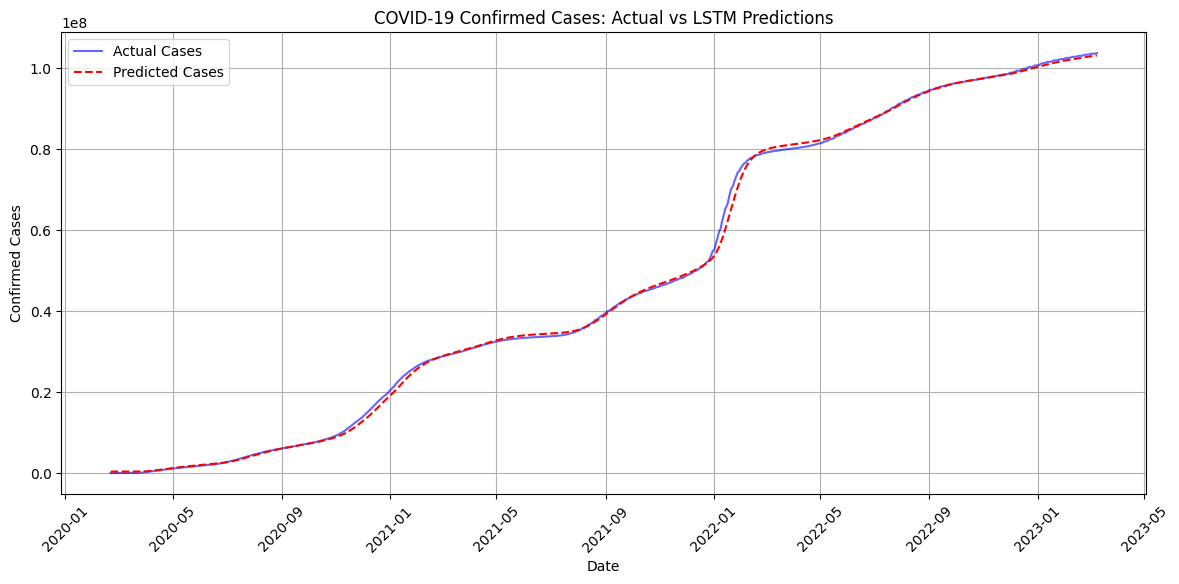

MSE: 713838144074.70
MAE: 491578.63


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# 상위 폴더의 visuals 폴더 경로
visuals_folder_path = '../visuals'

# 훈련 데이터에 대한 예측 수행
train_predict = model.predict(X)

# 원래 스케일로 역변환
train_predict = scaler.inverse_transform(train_predict)
y_actual = scaler.inverse_transform(y.reshape(-1, 1))

# 그래프 그리기
plt.figure(figsize=(14, 6))
plt.plot(us_data['Date'][30:], y_actual, label='Actual Cases', color='blue', alpha=0.6)
plt.plot(us_data['Date'][30:], train_predict, label='Predicted Cases', color='red', linestyle='--')
plt.title('COVID-19 Confirmed Cases: Actual vs LSTM Predictions')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# 그래프 저장
plt.savefig(os.path.join(visuals_folder_path, 'covid19_actual_vs_predicted.png'), bbox_inches='tight')
plt.show()
plt.close()  # 현재 그래프 닫기



# 성능 지표 출력
mse = mean_squared_error(y_actual, train_predict)
mae = mean_absolute_error(y_actual, train_predict)
print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')

In [6]:
!pip freeze > requirements.txt